In [1]:
# these are the heatmaps for cycle phase only
# could not create heatmpas for case vs control because no CpGs passed FDR p < 0.05 
# no pathways came up significant 

In [2]:
# ==========================================
# Cycle phase pathway heatmap setup
# ==========================================

import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

In [8]:
adata_path = "/mnt/efs/home/ubuntu/M_train80_smartsva_corrected_with_SH_annot_filtered-cyclephaseusage.h5ad"

ttest_cpg_path = "/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase/cycle_phase_ttest_FDR_0.05_selected_cpgs_n32386.csv"

uni_cpg_path = "/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase_univariate_logistic/cycle_phase_univariate_logistic_FDR_0.05_selected_cpgs_n29749.csv"

ttest_go_path = "/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/ttest_pathway_analysis_outputs/cycle_phase/FDR_ttest/cycle_phase_FDR_ttest_GO_FDR_significant.csv"

ttest_kegg_path = "/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/ttest_pathway_analysis_outputs/cycle_phase/FDR_ttest/cycle_phase_FDR_ttest_KEGG_FDR_significant.csv"

uni_go_path = "/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/ttest_pathway_analysis_outputs/cycle_phase/univariate_LR_FDR/cycle_phase_FDR_ttest_GO_FDR_significant.csv"

uni_kegg_path = "/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/ttest_pathway_analysis_outputs/cycle_phase/univariate_LR_FDR/cycle_phase_FDR_ttest_KEGG_FDR_significant.csv"

out_dir = "/mnt/efs/home/ubuntu/endo-me_data/cycle_phase_heatmaps"
os.makedirs(out_dir, exist_ok=True)

print("Output directory:", out_dir)

Output directory: /mnt/efs/home/ubuntu/endo-me_data/cycle_phase_heatmaps


In [9]:
paths = {
    "adata": adata_path,
    "ttest_cpgs": ttest_cpg_path,
    "univariate_cpgs": uni_cpg_path,
    "ttest_go": ttest_go_path,
    "ttest_kegg": ttest_kegg_path,
    "univariate_go": uni_go_path,
    "univariate_kegg": uni_kegg_path,
}

for name, path in paths.items():
    print(name, "FOUND" if os.path.exists(path) else "MISSING", path)

adata FOUND /mnt/efs/home/ubuntu/M_train80_smartsva_corrected_with_SH_annot_filtered-cyclephaseusage.h5ad
ttest_cpgs FOUND /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase/cycle_phase_ttest_FDR_0.05_selected_cpgs_n32386.csv
univariate_cpgs FOUND /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase_univariate_logistic/cycle_phase_univariate_logistic_FDR_0.05_selected_cpgs_n29749.csv
ttest_go FOUND /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/ttest_pathway_analysis_outputs/cycle_phase/FDR_ttest/cycle_phase_FDR_ttest_GO_FDR_significant.csv
ttest_kegg FOUND /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/ttest_pathway_analysis_outputs/cycle_phase/FDR_ttest/cycle_phase_FDR_ttest_KEGG_FDR_significant.csv
univariate_go FOUND /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/ttest_pathway_analysis_outputs/cycle_phase/univariate_LR_FDR/cycle_phase_FDR_ttest_GO_FDR_significant.csv
univari

In [19]:
ttest_go = pd.read_csv(ttest_go_path)
ttest_kegg = pd.read_csv(ttest_kegg_path)

uni_go = pd.read_csv(uni_go_path)
uni_kegg = pd.read_csv(uni_kegg_path)

print("T-test GO:", ttest_go.shape)
print("T-test KEGG:", ttest_kegg.shape)
print("Univariate GO:", uni_go.shape)
print("Univariate KEGG:", uni_kegg.shape)

display(ttest_go.head())
display(ttest_kegg.head())
display(uni_go.head())
display(uni_kegg.head())

T-test GO: (222, 7)
T-test KEGG: (13, 6)
Univariate GO: (164, 7)
Univariate KEGG: (16, 6)


,ONTOLOGY,TERM,N,DE,P.DE,FDR,SigGenesInSet
0,BP,anatomical structure morphogenesis,2837,1761,2.570799e-15,5.675553e-11,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."
1,BP,multicellular organism development,4859,2878,4.347988e-14,4.799527e-10,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."
2,BP,system development,4186,2512,8.428114e-14,6.202249e-10,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."
3,BP,anatomical structure development,6129,3529,2.163523e-13,1.194103e-09,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,C17orf9..."
4,BP,developmental process,6686,3809,5.664349e-13,2.501037e-09,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,C17orf9..."


,Description,N,DE,P.DE,FDR,SigGenesInSet
0,Proteoglycans in cancer,202,147,0.000005,0.001914,"AKT3,CDKN1A,VAV3,FRS2,COL1A1,MAPK14,CTNNB1,DCN..."
1,Pathways in cancer,520,339,0.000015,0.002750,"AKT3,BCL2L11,RASGRP1,CDK6,RASGRP2,CDKN1A,CDKN1..."
2,Integrin signaling,153,114,0.000135,0.015277,"AKT3,LAMC3,FERMT2,COL1A1,COL4A1,COL4A2,COL4A3,..."
3,Axon guidance,181,134,0.000165,0.015277,"PLXNC1,CDK5,PAK4,SEMA3A,SEMA6B,SEMA4F,SEMA4D,S..."
4,Ras signaling pathway,233,159,0.000254,0.018469,"AKT3,PLA2G4B,RASGRP1,RASGRP2,PAK4,GNB5,RALBP1,..."


,ONTOLOGY,TERM,N,DE,P.DE,FDR,SigGenesInSet
0,BP,anatomical structure morphogenesis,2837,1684,2.675243e-13,5.906133e-09,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."
1,BP,multicellular organism development,4859,2743,1.634828e-11,1.804605e-07,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."
2,BP,system development,4186,2393,3.937445e-11,2.620382e-07,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."
3,BP,developmental process,6686,3633,5.281596e-11,2.620382e-07,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."
4,BP,anatomical structure development,6129,3362,5.934643e-11,2.620382e-07,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."


,Description,N,DE,P.DE,FDR,SigGenesInSet
0,Proteoglycans in cancer,202,143,0.000003,0.001260,"AKT3,CDKN1A,VAV3,FRS2,COL1A1,MAPK14,CTNNB1,DCN..."
1,Pathways in cancer,520,328,0.000016,0.002937,"AKT3,BCL2L11,RASGRP1,CDK6,RASGRP2,CDKN1A,CDKN1..."
2,Ras signaling pathway,233,157,0.000056,0.006911,"AKT3,PLA2G4B,RASGRP1,RASGRP2,PAK4,GNB5,RALBP1,..."
3,Phospholipase D signaling pathway,147,107,0.000090,0.008308,"AKT3,PLA2G4B,RAPGEF3,AGPAT1,AGPAT2,GNA13,ADCY1..."
4,Axon guidance,181,129,0.000447,0.033095,"PLXNC1,CDK5,PAK4,SEMA3A,SEMA6B,SEMA4F,SEMA4D,S..."


In [20]:
sample_annot = adata.obs[["cycle-phase", "cycle_binary"]].copy()

cycle_order = {"proliferative": 0, "secretory": 1}
sample_annot["cycle_order"] = sample_annot["cycle_binary"].map(cycle_order)

ordered_samples = (
    sample_annot
    .sort_values(["cycle_order", "cycle-phase"])
    .index
    .tolist()
)

print(sample_annot["cycle_binary"].value_counts())
print("Ordered samples:", len(ordered_samples))

cycle_binary
proliferative    385
secretory        350
Name: count, dtype: int64
Ordered samples: 735


In [21]:
def extract_cpg_list(path):
    df = pd.read_csv(path)
    possible_cols = ["cpg", "CpG", "probe", "Probe", "CpG_ID", "cpg_id"]
    found = [c for c in possible_cols if c in df.columns]
    
    if len(found) == 0:
        raise ValueError(f"No CpG column found. Columns are: {df.columns.tolist()}")
    
    cpg_col = found[0]
    return df[cpg_col].dropna().astype(str).unique().tolist()

ttest_cpgs = extract_cpg_list(ttest_cpg_path)
uni_cpgs = extract_cpg_list(uni_cpg_path)

ttest_cpgs_in_data = [c for c in ttest_cpgs if c in adata.var_names]
uni_cpgs_in_data = [c for c in uni_cpgs if c in adata.var_names]

print("T-test CpGs in data:", len(ttest_cpgs_in_data))
print("Univariate LR CpGs in data:", len(uni_cpgs_in_data))

T-test CpGs in data: 32386
Univariate LR CpGs in data: 29749


In [22]:
for name, df in {
    "ttest_go": ttest_go,
    "ttest_kegg": ttest_kegg,
    "uni_go": uni_go,
    "uni_kegg": uni_kegg,
}.items():
    print("\n" + "="*60)
    print(name)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    display(df.head(3))


ttest_go
Shape: (222, 7)
Columns:
['ONTOLOGY', 'TERM', 'N', 'DE', 'P.DE', 'FDR', 'SigGenesInSet']


,ONTOLOGY,TERM,N,DE,P.DE,FDR,SigGenesInSet
0,BP,anatomical structure morphogenesis,2837,1761,2.570799e-15,5.675553e-11,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."
1,BP,multicellular organism development,4859,2878,4.347988e-14,4.799527e-10,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."
2,BP,system development,4186,2512,8.428114e-14,6.202249e-10,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."



ttest_kegg
Shape: (13, 6)
Columns:
['Description', 'N', 'DE', 'P.DE', 'FDR', 'SigGenesInSet']


,Description,N,DE,P.DE,FDR,SigGenesInSet
0,Proteoglycans in cancer,202,147,0.000005,0.001914,"AKT3,CDKN1A,VAV3,FRS2,COL1A1,MAPK14,CTNNB1,DCN..."
1,Pathways in cancer,520,339,0.000015,0.002750,"AKT3,BCL2L11,RASGRP1,CDK6,RASGRP2,CDKN1A,CDKN1..."
2,Integrin signaling,153,114,0.000135,0.015277,"AKT3,LAMC3,FERMT2,COL1A1,COL4A1,COL4A2,COL4A3,..."



uni_go
Shape: (164, 7)
Columns:
['ONTOLOGY', 'TERM', 'N', 'DE', 'P.DE', 'FDR', 'SigGenesInSet']


,ONTOLOGY,TERM,N,DE,P.DE,FDR,SigGenesInSet
0,BP,anatomical structure morphogenesis,2837,1684,2.675243e-13,5.906133e-09,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."
1,BP,multicellular organism development,4859,2743,1.634828e-11,1.804605e-07,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."
2,BP,system development,4186,2393,3.937445e-11,2.620382e-07,"ADA,CDH2,AKT3,NR2E3,MINAR2,HDAC6,HDAC5,PDCD6,B..."



uni_kegg
Shape: (16, 6)
Columns:
['Description', 'N', 'DE', 'P.DE', 'FDR', 'SigGenesInSet']


,Description,N,DE,P.DE,FDR,SigGenesInSet
0,Proteoglycans in cancer,202,143,0.000003,0.001260,"AKT3,CDKN1A,VAV3,FRS2,COL1A1,MAPK14,CTNNB1,DCN..."
1,Pathways in cancer,520,328,0.000016,0.002937,"AKT3,BCL2L11,RASGRP1,CDK6,RASGRP2,CDKN1A,CDKN1..."
2,Ras signaling pathway,233,157,0.000056,0.006911,"AKT3,PLA2G4B,RASGRP1,RASGRP2,PAK4,GNB5,RALBP1,..."


In [24]:
import subprocess
from pathlib import Path

annotation_out = "/mnt/efs/home/ubuntu/endo-me_data/EPIC_cpg_to_gene_annotation.csv"

r_script = f"""
library(minfi)
library(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)

anno <- getAnnotation(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)

anno_df <- data.frame(
  cpg = rownames(anno),
  gene_symbol = anno$UCSC_RefGene_Name,
  stringsAsFactors = FALSE
)

write.csv(anno_df, "{annotation_out}", row.names = FALSE)

cat("Saved annotation to:", "{annotation_out}", "\\n")
cat("Rows:", nrow(anno_df), "\\n")
"""

script_path = "/mnt/efs/home/ubuntu/endo-me_data/export_epic_annotation.R"

with open(script_path, "w") as f:
    f.write(r_script)

subprocess.run(["Rscript", script_path], check=True)

Loading required package: BiocGenerics
Loading required package: generics

Attaching package: ‘generics’

The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union


Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min

Loading required package: GenomicRanges
Loading required package: stats4
Loading required package: S4Vectors

Attaching package: ‘S4Vectors’

The following object is masked from ‘package:utils’

Saved annotation to: /mnt/efs/home/ubuntu/endo-me_data/EPIC_cpg_to_gene_annotation.csv 
Rows: 865859 


CompletedProcess(args=['Rscript', '/mnt/efs/home/ubuntu/endo-me_data/export_epic_annotation.R'], returncode=0)

In [25]:
cpg_gene_annot = pd.read_csv(annotation_out)

print(cpg_gene_annot.shape)
display(cpg_gene_annot.head())

(865859, 2)


,cpg,gene_symbol
0,cg18478105,YTHDF1
1,cg09835024,EIF2S3
2,cg14361672,PKN3
3,cg01763666,CCDC57
4,cg12950382,INF2;INF2


In [26]:
# Some CpGs map to multiple genes separated by semicolons
cpg_gene_long = (
    cpg_gene_annot
    .dropna(subset=["gene_symbol"])
    .assign(gene_symbol=lambda d: d["gene_symbol"].astype(str).str.split(";"))
    .explode("gene_symbol")
)

cpg_gene_long["gene_symbol"] = cpg_gene_long["gene_symbol"].str.strip()

# Remove blanks
cpg_gene_long = cpg_gene_long[cpg_gene_long["gene_symbol"] != ""]

# Keep only CpGs present in our AnnData
cpg_gene_long = cpg_gene_long[cpg_gene_long["cpg"].isin(adata.var_names)]

print("CpG-gene mapping rows:", cpg_gene_long.shape)
print("Unique CpGs mapped:", cpg_gene_long["cpg"].nunique())
print("Unique genes mapped:", cpg_gene_long["gene_symbol"].nunique())

display(cpg_gene_long.head())

CpG-gene mapping rows: (1226122, 2)
Unique CpGs mapped: 552031
Unique genes mapped: 26196


,cpg,gene_symbol
0,cg18478105,YTHDF1
1,cg09835024,EIF2S3
2,cg14361672,PKN3
3,cg01763666,CCDC57
5,cg02115394,CDC16


In [27]:
def build_pathway_matrix(pathway_df, adata, cpg_gene_long, pathway_col, n_pathways=20):
    
    # take top pathways by FDR
    pathway_df = pathway_df.sort_values("FDR").head(n_pathways)
    
    pathway_matrix = []
    pathway_names = []
    
    for _, row in pathway_df.iterrows():
        
        pathway_name = row[pathway_col]
        genes = str(row["SigGenesInSet"]).split(",")
        genes = [g.strip() for g in genes]
        
        # map genes → CpGs
        cpgs = cpg_gene_long[
            cpg_gene_long["gene_symbol"].isin(genes)
        ]["cpg"].unique()
        
        # keep only CpGs in data
        cpgs = [c for c in cpgs if c in adata.var_names]
        
        if len(cpgs) < 5:
            continue
        
        # extract methylation
        X = adata[:, cpgs].X
        
        if not isinstance(X, np.ndarray):
            X = X.toarray()
        
        # average across CpGs → pathway signal per sample
        pathway_signal = X.mean(axis=1)
        
        pathway_matrix.append(pathway_signal)
        pathway_names.append(pathway_name)
    
    pathway_matrix = np.array(pathway_matrix)
    
    return pathway_matrix, pathway_names

In [28]:
ttest_go_matrix, ttest_go_names = build_pathway_matrix(
    ttest_go,
    adata,
    cpg_gene_long,
    pathway_col="TERM",
    n_pathways=20
)

print("Matrix shape:", ttest_go_matrix.shape)
print("Pathways:", len(ttest_go_names))

Matrix shape: (20, 735)
Pathways: 20


In [29]:
def zscore_rows(mat):
    mean = mat.mean(axis=1, keepdims=True)
    std = mat.std(axis=1, keepdims=True)
    return (mat - mean) / (std + 1e-8)

ttest_go_matrix_z = zscore_rows(ttest_go_matrix)

print("Z-scored matrix shape:", ttest_go_matrix_z.shape)

Z-scored matrix shape: (20, 735)


/home/ubuntu/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/ubuntu/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1600x800 with 0 Axes>

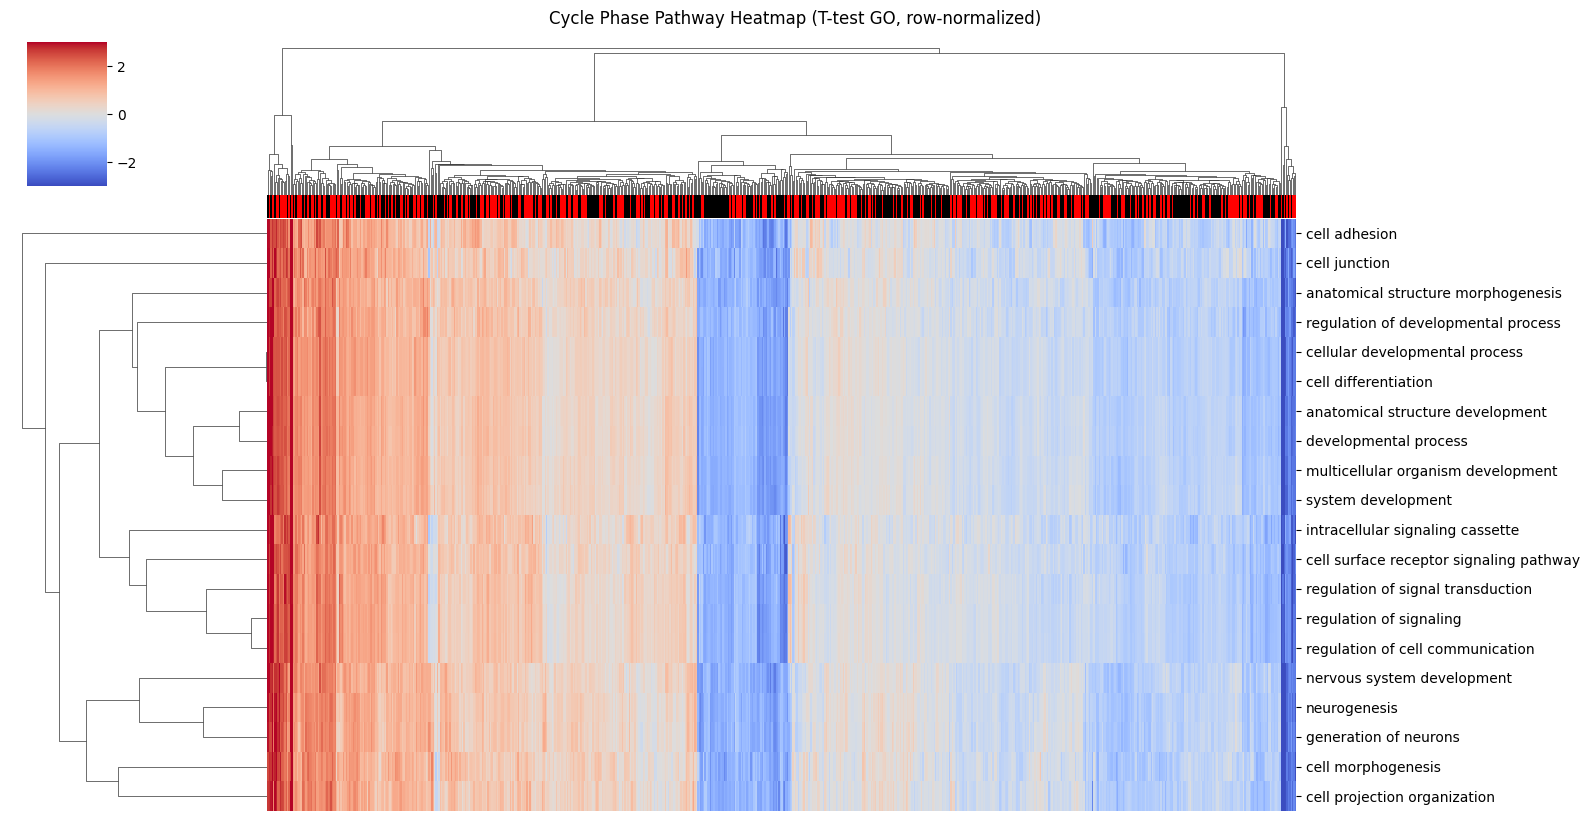

In [54]:
# reorder columns (samples)
ttest_go_matrix_z_ordered = ttest_go_matrix_z[:, [adata.obs_names.get_loc(s) for s in ordered_samples]]

# create dataframe for plotting
heatmap_df = pd.DataFrame(
    ttest_go_matrix_z_ordered,
    index=ttest_go_names,
    columns=ordered_samples
)

# plot
plt.figure(figsize=(16, 8))

# sample colors (recreate this if needed)
phase_colors = {
    "proliferative": "black",
    "secretory": "red"
}

col_colors = [phase_colors[adata.obs.loc[s, "cycle_binary"]] for s in ordered_samples]

# clustermap
g = sns.clustermap(
    heatmap_df,
    cmap="coolwarm",
    center=0,
    col_colors=col_colors,   # THIS brings back the bar
    col_cluster=True,       
    row_cluster=True,
    xticklabels=False,
    yticklabels=True,
    figsize=(16, 8),
    vmin=-3,
    vmax=3
)

g.fig.suptitle("Cycle Phase Pathway Heatmap (T-test GO, row-normalized)", y=1.02)

g.savefig(f"{out_dir}/cycle_phase_ttest_GO_heatmap.png", dpi=300)

plt.show()

Selected CpGs: 1000


/home/ubuntu/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/ubuntu/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


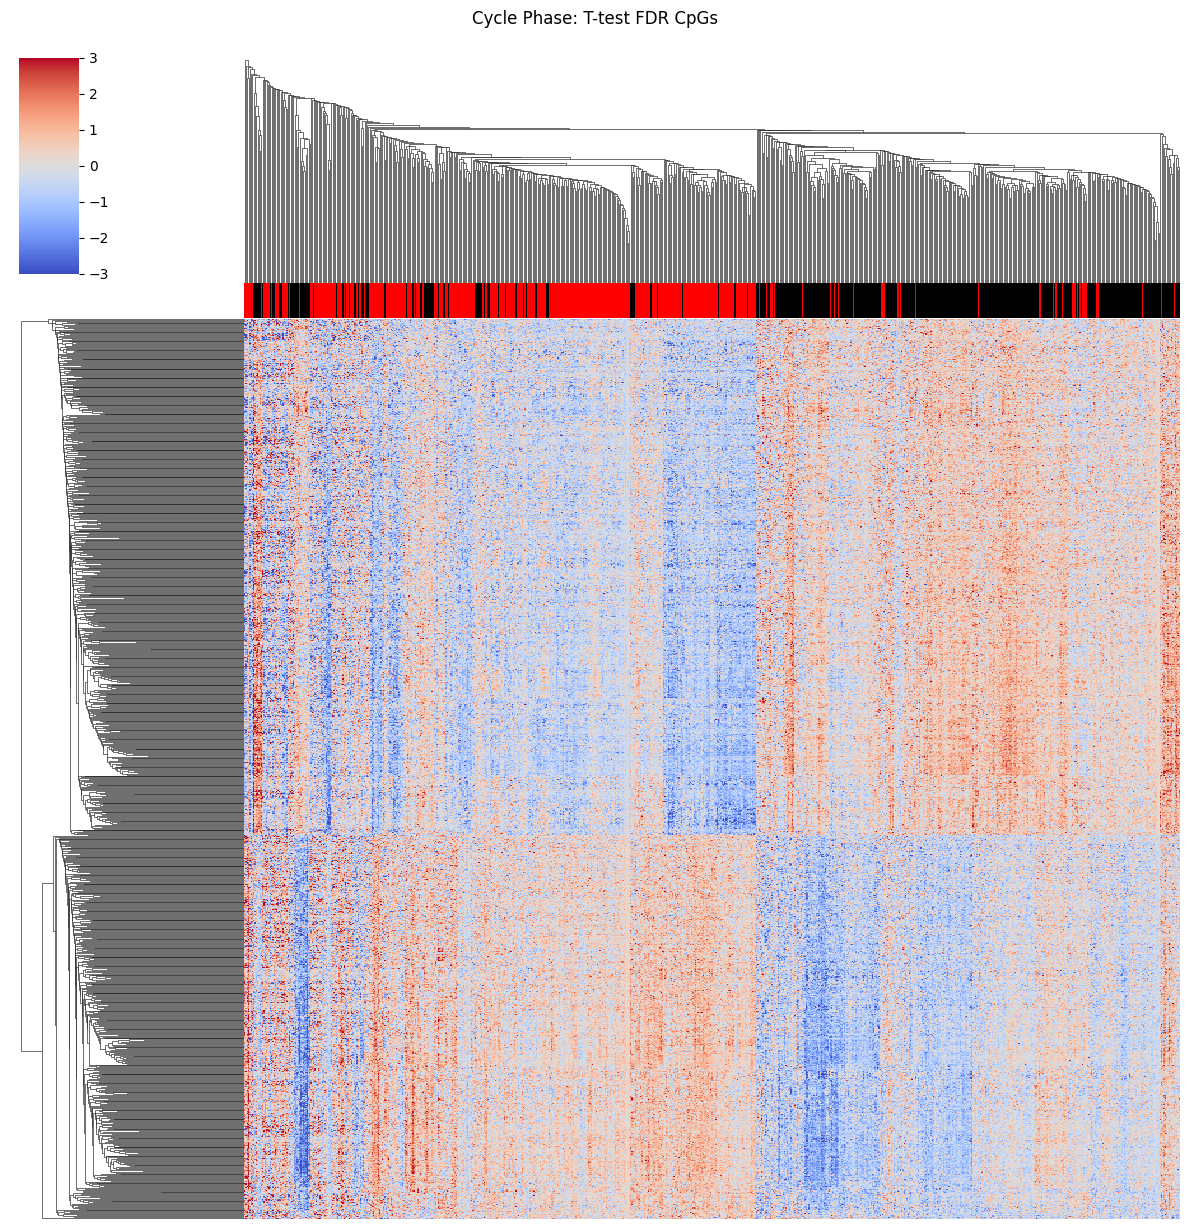

In [45]:
# CpG x sample heatmap (cycle phase, t-test FDR CpGs)

ttest_df = pd.read_csv(ttest_cpg_path)

# find CpG column
cpg_col = [c for c in ["cpg", "CpG", "probe", "Probe", "CpG_ID", "cpg_id"] if c in ttest_df.columns][0]

# keep only CpGs in AnnData
selected_cpgs = ttest_df[cpg_col].astype(str)
selected_cpgs = [c for c in selected_cpgs if c in adata.var_names]

# limit for plotting (important)
selected_cpgs = selected_cpgs[:1000]

print("Selected CpGs:", len(selected_cpgs))

# extract matrix
X = adata[ordered_samples, selected_cpgs].X
if not isinstance(X, np.ndarray):
    X = X.toarray()

# rows = CpGs
mat = X.T

# row-normalize
mat_z = (mat - mat.mean(axis=1, keepdims=True)) / (mat.std(axis=1, keepdims=True) + 1e-8)

heatmap_df_cpg = pd.DataFrame(
    mat_z,
    index=selected_cpgs,
    columns=ordered_samples
)

# sample colors
phase_colors = {
    "proliferative": "black",
    "secretory": "red"
}

col_colors = [phase_colors[adata.obs.loc[s, "cycle_binary"]] for s in ordered_samples]

# plot
g = sns.clustermap(
    heatmap_df_cpg,
    cmap="coolwarm",
    center=0,
    col_colors=col_colors,
    col_cluster=True,   # IMPORTANT
    row_cluster=True,
    xticklabels=False,
    yticklabels=False,
    figsize=(12, 12),
    vmin=-3,
    vmax=3
)

g.fig.suptitle("Cycle Phase: T-test FDR CpGs", y=1.02)
g.savefig(f"{out_dir}/cycle_phase_ttest_cpg_sample_heatmap.png", dpi=300)

plt.show()

### univariate heatmaps 

Univariate GO matrix shape: (20, 735)
Univariate GO pathways: 20


/home/ubuntu/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/ubuntu/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


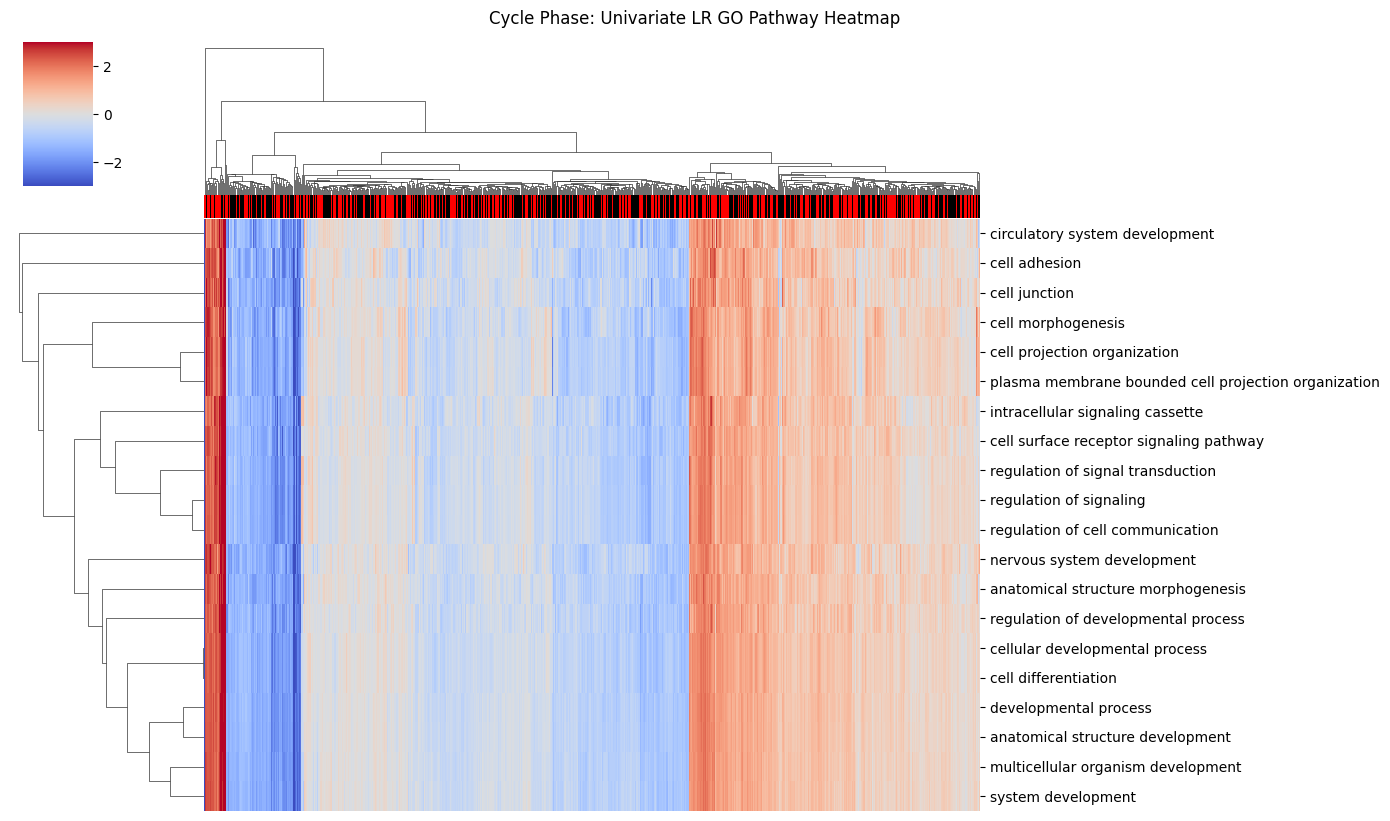

In [49]:
# Build univariate LR GO pathway matrix

uni_go_matrix, uni_go_names = build_pathway_matrix(
    uni_go,
    adata,
    cpg_gene_long,
    pathway_col="TERM",
    n_pathways=20
)

print("Univariate GO matrix shape:", uni_go_matrix.shape)
print("Univariate GO pathways:", len(uni_go_names))

# row-normalize pathways
uni_go_matrix_z = zscore_rows(uni_go_matrix)

# reorder columns by proliferative then secretory
uni_go_matrix_z_ordered = uni_go_matrix_z[:, [adata.obs_names.get_loc(s) for s in ordered_samples]]

# dataframe for plotting
uni_go_heatmap_df = pd.DataFrame(
    uni_go_matrix_z_ordered,
    index=uni_go_names,
    columns=ordered_samples
)

# sample annotation colors
phase_colors = {
    "proliferative": "black",
    "secretory": "red"
}

col_colors = [phase_colors[adata.obs.loc[s, "cycle_binary"]] for s in ordered_samples]

# plot pathway heatmap
g = sns.clustermap(
    uni_go_heatmap_df,
    cmap="coolwarm",
    center=0,
    col_colors=col_colors,
    col_cluster=True,
    row_cluster=True,
    xticklabels=False,
    yticklabels=True,
    figsize=(14, 8),
    vmin=-3,
    vmax=3
)

g.fig.suptitle("Cycle Phase: Univariate LR GO Pathway Heatmap", y=1.02)
g.savefig(f"{out_dir}/cycle_phase_univariateLR_GO_pathway_sample_heatmap.png", dpi=300)

plt.show()

Selected CpGs: 1000


/home/ubuntu/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/ubuntu/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


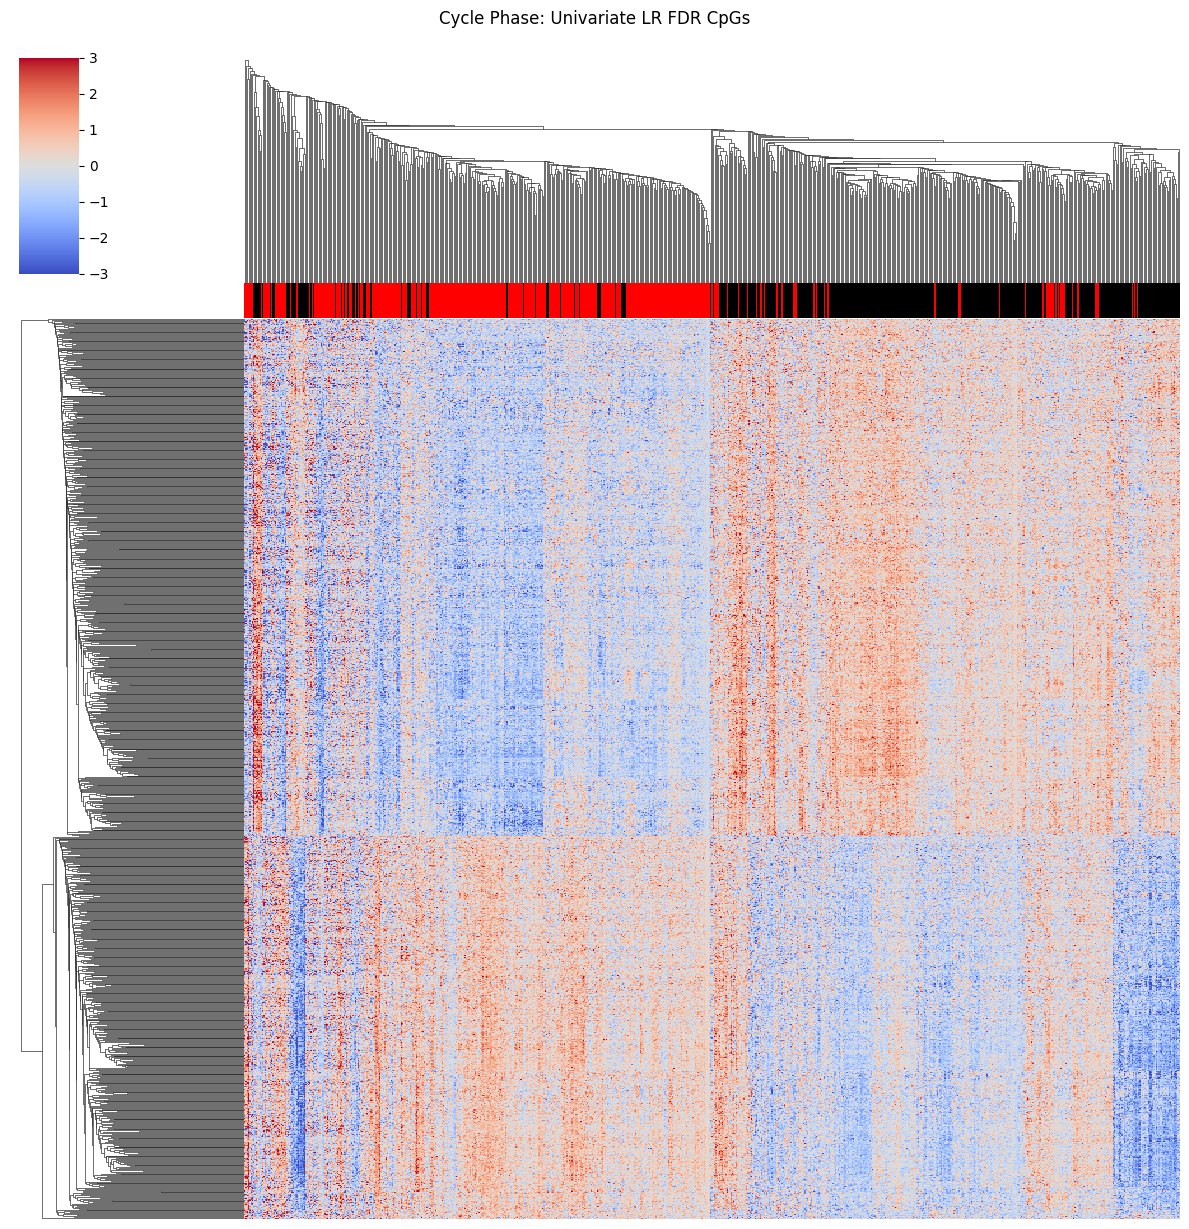

In [47]:
# CpG x sample heatmap (cycle phase, univariate LR FDR CpGs)

uni_df = pd.read_csv(uni_cpg_path)

# find CpG column
cpg_col = [c for c in ["cpg", "CpG", "probe", "Probe", "CpG_ID", "cpg_id"] if c in uni_df.columns][0]

# keep only CpGs in AnnData
selected_cpgs = uni_df[cpg_col].astype(str)
selected_cpgs = [c for c in selected_cpgs if c in adata.var_names]

# limit for plotting
selected_cpgs = selected_cpgs[:1000]

print("Selected CpGs:", len(selected_cpgs))

# extract matrix
X = adata[ordered_samples, selected_cpgs].X
if not isinstance(X, np.ndarray):
    X = X.toarray()

# rows = CpGs, columns = samples
mat = X.T

# row-normalize each CpG
mat_z = (mat - mat.mean(axis=1, keepdims=True)) / (mat.std(axis=1, keepdims=True) + 1e-8)

heatmap_df_uni_cpg = pd.DataFrame(
    mat_z,
    index=selected_cpgs,
    columns=ordered_samples
)

phase_colors = {
    "proliferative": "black",
    "secretory": "red"
}

col_colors = [phase_colors[adata.obs.loc[s, "cycle_binary"]] for s in ordered_samples]

g = sns.clustermap(
    heatmap_df_uni_cpg,
    cmap="coolwarm",
    center=0,
    col_colors=col_colors,
    col_cluster=True,
    row_cluster=True,
    xticklabels=False,
    yticklabels=False,
    figsize=(12, 12),
    vmin=-3,
    vmax=3
)

g.fig.suptitle("Cycle Phase: Univariate LR FDR CpGs", y=1.02)
g.savefig(f"{out_dir}/cycle_phase_univariateLR_cpg_sample_heatmap.png", dpi=300)

plt.show()